In [1]:
import mujoco as mj
import mediapy as media
def render(model, data=None, height=300, camera=-1):
  if data is None:
    data = mj.MjData(model)
  with mj.Renderer(model, 480, 640) as renderer:
    mj.mj_forward(model, data)
    renderer.update_scene(data, camera="closeup")
    media.show_image(renderer.render(), height=height)

from IPython.display import clear_output, HTML, display
clear_output()

import pygments
def print_xml(xml_string):
  formatter = pygments.formatters.HtmlFormatter()
  lexer = pygments.lexers.XmlLexer()
  highlighted = pygments.highlight(xml_string, lexer, formatter)
  display(HTML(f"<style>{formatter.get_style_defs()}</style>{highlighted}"))

In [2]:
#@title Parse, compile, modify, compile: {vertical-output: true}

static_model = """
<mujoco model="v2_4">
    <compiler angle="radian"/>
    <option timestep="0.001" iterations="2000" gravity="0 0 -9.8" tolerance="1e-10"/>
    
    <default>
        <geom density="418"/>
    </default>

    <asset>
        <texture name="grid" type="2d" builtin="checker" rgb1=".1 .2 .3"
            rgb2=".2 .3 .4" width="300" height="300"/>
        <material name="grid" texture="grid" texrepeat="8 8" reflectance=".2"/>
    </asset>

    <worldbody>
        <light name="top" pos="0 0 5" diffuse="1 1 1" ambient="0.5 0.5 0.5"/>
        <camera name="closeup" pos="1.483 -0.033 0.580" xyaxes="0.040 0.999 -0.000 -0.129 0.005 0.992"/>

        <geom size="10 10 .01" type="plane" material="grid" friction="1 0.005 0.0001"/>

        <body name="Base" pos="0 0 0.8">
            <geom size="0.01 0.2 0.01" type="box" rgba="0.8 0 0 0.8" mass="0.155" contype="0" conaffinity="0"/>
            <body name="RB_Thigh" pos="0 0 0">
                <geom size="0.005" type="capsule" rgba="0.8 0 0 0.8" mass="0.086" fromto="0 0 0 0 0 -0.25" contype="0" conaffinity="0"/>
                <joint name="RB_Shoulder" type="hinge" axis="1 0 0" range="-1.57 1.57"/>
                <body name="RB_Calf" pos="0 0 -0.25">
                    <geom size="0.005" type="capsule" rgba="0.8 0 0 0.8" mass="0.1033" fromto="0 0 0 0 0 -0.25" contype="0" conaffinity="0"/>
                    <joint name="RB_Elbow" type="hinge" axis="1 0 0" range="-1.57 1.57"/>
                    <body name="Leg" pos="0 0 -0.25">
                        <geom size="0.005" type="capsule" rgba="0.8 0 0 0.8" mass="0.1033" fromto="0 0 0 0 0 -0.25" contype="0" conaffinity="0"/>
                        <joint name="Leg_joint" type="hinge" axis="1 0 0" range="-1.57 1.57"/>
                    </body>
                    <body name="Leg_RB_BAA_UPLink" pos="0 0.1 -0.1" axisangle="1 0 0 -0.1973955598">
                        <geom size="0.005" type="sphere" rgba="0.5 0.5 0 0.8" mass="0.03" contype="0" conaffinity="0"/>
                        <site name="Leg_RB_BAA_anchor1" pos="0 0 0"/>
                        <joint name="Leg_RB_BAA_UPJoint" type="hinge" axis="1 0 0"/>
                        <body name="Leg_RB_BAA_FMLink" pos="0 0 -0.1274754878">
                            <geom size="0.005" type="sphere" rgba="0.5 0.5 0 0.8" mass="0.12" contype="0" conaffinity="0"/>
                            <joint name="Leg_RB_BAA_SlideJoint" type="slide" axis="0 0 -1" damping="0" stiffness="0" springref="0"/>
                            <body name="Leg_RB_BAA_LOLink" pos="0 0 -0.1274754878">
                                <geom size="0.005" type="sphere" rgba="0.5 0.5 0 0.8" mass="0.03" contype="0" conaffinity="0"/>
                                <joint name="Leg_RB_BAA_FM_SlideJoint" type="slide" axis="0 0 -1" damping="0" stiffness="0" springref="0"/>
                                <site name="Leg_RB_BAA_anchor2" pos="0 0 0"/>
                            </body>
                        </body>
                    </body>
                </body>
               
            </body>
            <body name="RB_MAA_UPLink" pos="0 -0.06 0" axisangle="1 0 0 0.1419014548">
                <geom size="0.005" type="sphere" rgba="0.8 0 0 0.8" mass="0.03108" contype="0" conaffinity="0"/>
                <site name="RB_MAA_anchor1" pos="0 0 0"/>
                <joint name="RB_MAA_UpJoint" type="hinge" axis="1 0 0"/>
                <body name="RB_MAA_FM_Link" pos="0 0 -0.1060650937413537">
                    <geom size="0.005" type="sphere" rgba="0.8 0 0 0.8" mass="0.12432" contype="0" conaffinity="0"/>
                    <joint name="RB_MAA_SlideJoint" type="slide" axis="0 0 -1" damping="22.68" stiffness="637.52" springref="-0.019065093741353706"/>
                    <body name="RB_MAA_LOLink" pos="0 0 -0.1060650937413537">
                        <geom size="0.005" type="sphere" rgba="0.8 0 0 0.8" mass="0.03108" contype="0" conaffinity="0"/>
                        <joint name="RB_MAA_FM_SlideJoint" type="slide" axis="0 0 -1" damping="22.68" stiffness="637.52" springref="-0.019065093741353706"/>
                        <site name="RB_MAA_anchor2" pos="0 0 0"/>
                    </body>
                </body>
            </body>
            <body name="RB_BAA_UPLink" pos="0 0.1 0" axisangle="1 0 0 -0.147464847">
                <geom size="0.005" type="sphere" rgba="0 0 0.5 0.8" mass="0.04544333333" contype="0" conaffinity="0"/>
                <site name="RB_BAA_anchor1" pos="0 0 0"/>
                <joint name="RB_BAA_UpJoint" type="hinge" axis="1 0 0"/>
                <body name="RB_BAA_FM_LINK" pos="0 0 -0.17014792842496052">
                    <geom size="0.005" type="sphere" rgba="0 0 0.5 0.8" mass="0.1817733333" contype="0" conaffinity="0"/>
                    <joint name="RB_BAA_SlideJoint" type="slide" axis="0 0 -1" damping="21.8" stiffness="631.6" springref="-0.04204792842496052"/>
                    <body name="RB_BAA_LOLink" pos="0 0 -0.17014792842496052">
                        <geom size="0.005" type="sphere" rgba="0 0 0.5 0.8" mass="0.04544333333" contype="0" conaffinity="0"/>
                        <joint name="RB_BAA_FM_SlideJoint" type="slide" axis="0 0 -1" damping="21.8" stiffness="631.6" springref="-0.04204792842496052"/>
                        <site name="RB_BAA_anchor2" pos="0 0 0"/>
                    </body>
                </body>
            </body>
        </body>

    </worldbody>

          <!-- 增加在RB_RB_BAA_LowerJoint等关节中加入8个位置控制器，要求增加位置限制 -->
    <actuator>
        <motor joint="RB_MAA_SlideJoint" ctrllimited="true" ctrlrange="-200 200" />
        <motor joint="RB_MAA_FM_SlideJoint" ctrllimited="true" ctrlrange="-200 200" />
        <motor joint="RB_BAA_SlideJoint" ctrllimited="true" ctrlrange="-200 200" />
        <motor joint="RB_BAA_FM_SlideJoint" ctrllimited="true" ctrlrange="-200 200" />
        <motor joint="Leg_RB_BAA_SlideJoint" ctrllimited="true" ctrlrange="-200 200" />
        <motor joint="Leg_RB_BAA_FM_SlideJoint" ctrllimited="true" ctrlrange="-200 200" />
    </actuator>

    <!-- 建立并联关系，如 RB_RB_BAA_LOLink 应该与 RB_Calf 连接 --> 
    <equality>
        <connect name="RB_BAA_connect" anchor="0 0 0" body2="RB_Calf" body1="RB_BAA_LOLink" solimp="0.95 0.99 0.00001 0.1 2"/>
        <connect name="RB_MAA_connect" anchor="0 0 0" body2="RB_Thigh" body1="RB_MAA_LOLink" solimp="0.95 0.99 0.00001 0.1 2"/>
        <connect name="Leg_RB_BAA_connect" anchor="0 0 0" body2="Leg" body1="Leg_RB_BAA_LOLink" solimp="0.95 0.99 0.00001 0.1 2"/>
        
        <!-- FM 的相等约束 -->
        <joint name="MAA" joint1="RB_MAA_SlideJoint" joint2="RB_MAA_FM_SlideJoint" solimp="0.95 0.99 0.00001 0.1 2"/>
        <joint name="BAA" joint1="RB_BAA_SlideJoint" joint2="RB_BAA_FM_SlideJoint" solimp="0.95 0.99 0.00001 0.1 2"/>
        <joint name="Leg_RB_BAA" joint1="Leg_RB_BAA_SlideJoint" joint2="Leg_RB_BAA_FM_SlideJoint" solimp="0.95 0.99 0.00001 0.1 2"/>
    </equality>

    <!-- visualization -->
    <tendon>
        <spatial stiffness="0" width="0.003">
            <site site="RB_MAA_anchor1"/>
            <site site="RB_MAA_anchor2"/>
        </spatial>
        <spatial stiffness="0" width="0.003">
            <site site="RB_BAA_anchor1"/>
            <site site="RB_BAA_anchor2"/>
        </spatial>
        <spatial stiffness="0" width="0.003">
            <site site="Leg_RB_BAA_anchor1"/>
            <site site="Leg_RB_BAA_anchor2"/>
        </spatial>
    </tendon>

</mujoco>
"""


""

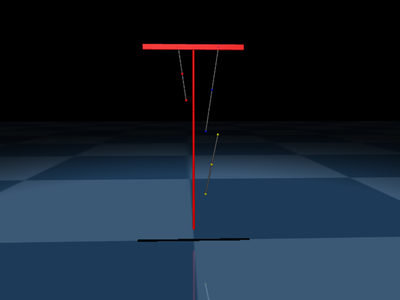

""

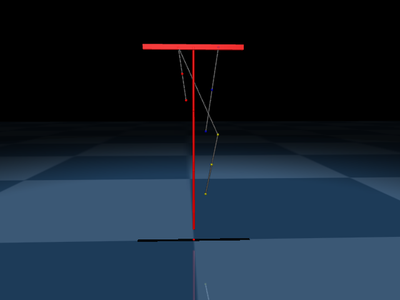

In [3]:

spec = mj.MjSpec.from_string(static_model)
model = spec.compile()
render(model)

# Change the mjSpec, re-compile and re-render
spec.modelname = "edited model"

# add body and geom
name = 'thigh_body'
pos = [0, 0, 0]
axisangle = [1, 0, 0, 0]

thigh_body = spec.worldbody.add_body(name=name, pos=pos, axisangle=axisangle)

# add geom
name = 'test_geom'
size = [0.005, 0, 0]
type = mj.mjtGeom.mjGEOM_SPHERE
rgba = [0.8, 0, 0, 0.8]
mass = 0.03108
contype = 0
conaffinity = 0
thigh_body.add_geom(name=name, type=type, size=size, rgba=rgba, mass=mass, contype=contype, conaffinity=conaffinity)

# add tendon
name = 'test_tendon'
stiffness = 0.0
width = 0.003
thread = spec.add_tendon(name=name, stiffness=stiffness, width=width)
thread.wrap_site('RB_MAA_anchor1')
thread.wrap_site('Leg_RB_BAA_anchor1')

# add equality
name = 'test_equality'
joint1 = 'RB_MAA_SlideJoint'
joint2 = 'RB_MAA_FM_SlideJoint'
solimp = [0.95, 0.99, 0.00001, 0.1, 2]
spec.add_equality(name=name, type =mj.mjtEq.mjEQ_JOINT, name1=joint1, name2=joint2, solimp=solimp)

model = spec.compile()
render(model)
print_xml(spec.to_xml())

In [4]:
# build a basic element of 3 segment muscle like this
'''
<body name="RB_BAA_UPLink" pos="0 0.1 0" axisangle="1 0 0 -0.147464847">
    <geom size="0.005" type="sphere" rgba="0 0 0.5 0.8" mass="0.04544333333" contype="0" conaffinity="0"/>
    <site name="RB_BAA_anchor1" pos="0 0 0"/>
    <joint name="RB_BAA_UpJoint" type="hinge" axis="1 0 0"/>
    <body name="RB_BAA_FM_LINK" pos="0 0 -0.17014792842496052">
        <geom size="0.005" type="sphere" rgba="0 0 0.5 0.8" mass="0.1817733333" contype="0" conaffinity="0"/>
        <joint name="RB_BAA_SlideJoint" type="slide" axis="0 0 -1" damping="21.8" stiffness="631.6" springref="-0.04204792842496052"/>
        <body name="RB_BAA_LOLink" pos="0 0 -0.17014792842496052">
            <geom size="0.005" type="sphere" rgba="0 0 0.5 0.8" mass="0.04544333333" contype="0" conaffinity="0"/>
            <joint name="RB_BAA_FM_SlideJoint" type="slide" axis="0 0 -1" damping="21.8" stiffness="631.6" springref="-0.04204792842496052"/>
            <site name="RB_BAA_anchor2" pos="0 0 0"/>
        </body>
    </body>
</body>
'''

'\n<body name="RB_BAA_UPLink" pos="0 0.1 0" axisangle="1 0 0 -0.147464847">\n    <geom size="0.005" type="sphere" rgba="0 0 0.5 0.8" mass="0.04544333333" contype="0" conaffinity="0"/>\n    <site name="RB_BAA_anchor1" pos="0 0 0"/>\n    <joint name="RB_BAA_UpJoint" type="hinge" axis="1 0 0"/>\n    <body name="RB_BAA_FM_LINK" pos="0 0 -0.17014792842496052">\n        <geom size="0.005" type="sphere" rgba="0 0 0.5 0.8" mass="0.1817733333" contype="0" conaffinity="0"/>\n        <joint name="RB_BAA_SlideJoint" type="slide" axis="0 0 -1" damping="21.8" stiffness="631.6" springref="-0.04204792842496052"/>\n        <body name="RB_BAA_LOLink" pos="0 0 -0.17014792842496052">\n            <geom size="0.005" type="sphere" rgba="0 0 0.5 0.8" mass="0.04544333333" contype="0" conaffinity="0"/>\n            <joint name="RB_BAA_FM_SlideJoint" type="slide" axis="0 0 -1" damping="21.8" stiffness="631.6" springref="-0.04204792842496052"/>\n            <site name="RB_BAA_anchor2" pos="0 0 0"/>\n        </bo

In [5]:
# solve the actuator
import xml.etree.ElementTree as ET

def add_motors_to_spec(spec: mj.MjSpec, joints: list[str], 
                            ctrlrange=(-200, 200), gear=1.0, prefix="motor_") -> mj.MjSpec:
    """
    向 MjSpec 模型中添加 motor actuator（通过解析 XML 插入）。
    
    Args:
        spec: MjSpec 实例
        joints: 需要控制的 joint 名称列表
        ctrlrange: 控制范围，例如 (-200, 200)
        gear: motor gear 值
        prefix: motor 的命名前缀

    Returns:
        新构建的 MjSpec 对象，包含 motor actuator
    """
    xml_str = spec.to_xml()
    root = ET.fromstring(xml_str)

    # 查找或创建 <actuator> 节点
    actuator_node = root.find("actuator")
    if actuator_node is None:
        actuator_node = ET.SubElement(root, "actuator")

    # 添加 motor 控制器
    for joint_name in joints:
        motor = ET.SubElement(actuator_node, "motor")
        motor.set("name", prefix + joint_name)
        motor.set("joint", joint_name)
        motor.set("ctrllimited", "true")
        motor.set("ctrlrange", f"{ctrlrange[0]} {ctrlrange[1]}")
        motor.set("gear", str(gear))

    # 重新构造 spec
    modified_xml = ET.tostring(root, encoding="unicode")
    return mj.MjSpec.from_string(modified_xml)

""

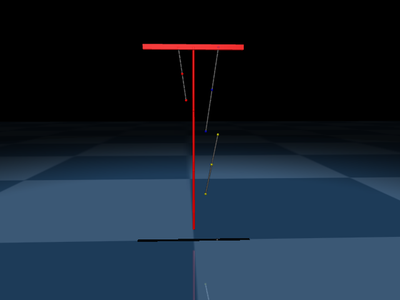

In [6]:
spec = mj.MjSpec.from_string(static_model)

# assume we have muscle_x
muscle_x = {
    'name': "muscleX",
    'mass': 0.18,
    'stiffness': 300,
    'damping': 0.5,
    'rest_length': 0.18,
}

_body = spec.worldbody.add_body(name=f"{muscle_x['name']}_uLink", 
                                pos=[0, 0.1, 0], axisangle=[1, 0, 0, -0.147464847])
_body.add_joint(name = f"{muscle_x['name']}_uRotJoint",
    type=mj.mjtJoint.mjJNT_HINGE,
    pos = [0, 0, 0],
    axis = [1, 0, 0])

_body.add_geom(name=f"{muscle_x['name']}_uGeom",
               type=mj.mjtGeom.mjGEOM_SPHERE,
               size=[0.005, 0, 0],
               mass = muscle_x['mass'] / 6,
               contype = 0,
               conaffinity = 0)

_body.add_site(name=f"{muscle_x['name']}_uSite", pos = [0, 0, 0])

# 迭代
_body = _body.add_body(name=f"{muscle_x['name']}_mLink", pos=[0, 0.1, 0])
_body.add_joint(name = f"{muscle_x['name']}_mSlideJoint",
    type=mj.mjtJoint.mjJNT_SLIDE,
    pos = [0, 0, 0],
    axis = [0, 0, -1],
    springref = 0.18,
    stiffness = muscle_x['stiffness'] * 2,
    damping = muscle_x['damping'] * 2,
    )

_body.add_geom(name=f"{muscle_x['name']}_mGeom",
               type=mj.mjtGeom.mjGEOM_SPHERE,
               size=[0.005, 0, 0],
               mass = muscle_x['mass'] * 2 / 3,
               contype = 0,
               conaffinity = 0)

_body.add_site(name=f"{muscle_x['name']}_mSite", pos = [0, 0, 0])

# 迭代
_body = _body.add_body(name=f"{muscle_x['name']}_lLink", pos=[0, 0.1, 0])
_body.add_joint(name = f"{muscle_x['name']}_lSlideJoint",
    type=mj.mjtJoint.mjJNT_SLIDE,
    pos = [0, 0, 0],
    axis = [0, 0, -1],
    springref = 0.18,
    stiffness = muscle_x['stiffness'] * 2,
    damping = muscle_x['damping'] * 2,
    )

_body.add_geom(name=f"{muscle_x['name']}_lGeom",
               type=mj.mjtGeom.mjGEOM_SPHERE,
               size=[0.005, 0, 0],
               mass = muscle_x['mass'] * 1 / 6,
               contype = 0,
               conaffinity = 0)

_body.add_site(name=f"{muscle_x['name']}_lSite", pos = [0, 0, 0])


print_xml(spec.to_xml())
model = spec.compile()
render(model)

In [7]:
DEFAULT_BALL_SIZE = 0.005     # for the mass point visualization

def add_muscle_to_spec(spec, muscle_cfg):
    # unpack
    name = muscle_cfg['name']
    mass = muscle_cfg['mass']
    stiffness = muscle_cfg['stiffness']
    damping = muscle_cfg['damping']
    rest_length = muscle_cfg['rest_length']
    init_length = muscle_cfg['init_length']
    # where it connects
    base_pos = muscle_cfg.get('base_pos')
    base_axisangle = muscle_cfg.get('base_axisangle')

    # preprocess
    uLink_mass, mLink_mass, lLink_mass = mass/6, mass*2/3, mass/6
    mSlideJoint_stiffness, lSlideJoint_stiffness = stiffness*2, stiffness*2
    mSlideJoint_damping, lSlideJoint_damping = damping*2, damping*2
    
    # NOTE: need to keep the axis of the muscle to be [0 0 -1] relative to the parent frame
    mLink_pos = [0, 0, -init_length/2]
    lLink_pos = [0, 0, -init_length/2]
    # NOTE: 'spring_ref' is the relative length of the muscle when it is at rest, to the init length
    init_relative_length = rest_length - init_length
    mSlideJoint_initRelaLength, lSlideJoint_initRelaLength = init_relative_length/2, init_relative_length/2

    # upper part
    _body = spec.add_body(name=f"{name}_uLink", pos=base_pos, axisangle=base_axisangle)
    print(f"base_axisangle: {base_axisangle}")
    _body.add_joint(name = f"{name}_uRotJoint",
        type=mj.mjtJoint.mjJNT_HINGE,
        pos = [0, 0, 0],
        axis = [1, 0, 0])
        # NOTE: we assume the motion is in the YOZ plane, so any rotate joint has a x-rotJoint
    _body.add_geom(name=f"{name}_uGeom",
                type=mj.mjtGeom.mjGEOM_SPHERE,
                size=[DEFAULT_BALL_SIZE, 0, 0],
                mass = uLink_mass,
                contype = 0,
                conaffinity = 0)
    _body.add_site(name=f"{name}_uSite", pos = [0, 0, 0])

    # middle part
    _body = _body.add_body(name=f"{name}_mLink", pos=mLink_pos)
    _body.add_joint(name = f"{name}_mSlideJoint",
        type=mj.mjtJoint.mjJNT_SLIDE,
        pos = [0, 0, 0],
        axis = [0, 0, -1],      
        # NOTE: need to keep the axis of the muscle to be [0 0 -1] relative to the parent frame
        springref = mSlideJoint_initRelaLength,
        stiffness = mSlideJoint_stiffness,
        damping = mSlideJoint_damping,
        )
    _body.add_geom(name=f"{name}_mGeom",
                type=mj.mjtGeom.mjGEOM_SPHERE,
                size=[DEFAULT_BALL_SIZE, 0, 0],
                mass = mLink_mass,
                # NOTE: ignore all collision in this theoretical verification
                contype = 0,
                conaffinity = 0)
    _body.add_site(name=f"{name}_mSite", pos = [0, 0, 0])

    # lower part
    _body = _body.add_body(name=f"{name}_lLink", pos=lLink_pos)
    _body.add_joint(name = f"{name}_lSlideJoint",
        type=mj.mjtJoint.mjJNT_SLIDE,
        pos = [0, 0, 0],
        axis = [0, 0, -1],
        springref = lSlideJoint_initRelaLength,
        stiffness = lSlideJoint_stiffness,
        damping = lSlideJoint_damping,
        )
    _body.add_geom(name=f"{name}_lGeom",
                type=mj.mjtGeom.mjGEOM_SPHERE,
                size=[DEFAULT_BALL_SIZE, 0, 0],
                mass = lLink_mass,
                contype = 0,
                conaffinity = 0)
    _body.add_site(name=f"{name}_lSite", pos = [0, 0, 0])

    # add actuators
    # _body.add_actuator(name=f"{name}_m

# 进行封装测试
spec = mj.MjSpec.from_string(static_model)

# assume we have muscle_x
muscleX_cfg = {
    'name': "muscleX",
    'mass': 0.27266,
    'stiffness': 315.8,
    'damping': 10.9,
    'init_length': 0.340296,
    'rest_length': 0.2562,
    'base_pos': [0, 0.1, 0],
    'base_axisangle': [1, 0, 0, -0.147464847],
}


# add_muscle_to_spec(spec.worldbody, muscleX_cfg)
# add_muscle_to_spec(spec.body("RB_Calf"), muscleX_cfg)


DEFAULT_TENDON_SIZE = 0.003
DEFAULT_TENDON_STIFFNESS = 0

def add_tendon_to_spec(spec, tendon_cfg):
    name = tendon_cfg['name']
    width = tendon_cfg['width']
    stiffness = tendon_cfg['stiffness']
    site1_name = tendon_cfg['site1_name']
    site2_name = tendon_cfg['site2_name']

    _tendon = spec.add_tendon(name=name, stiffness=stiffness, width=width)
    _tendon.wrap_site(site1_name)
    _tendon.wrap_site(site2_name)

# tendon_cfg = {
#     'name': "tendonX",
#     'width': DEFAULT_TENDON_SIZE,
#     'stiffness': DEFAULT_TENDON_STIFFNESS,
#     'site1_name': "muscleX_uSite",
#     'site2_name': "muscleX_lSite",
# }

# add_tendon_to_spec(spec, tendon_cfg)

def add_equality_spec(spec, equality_cfg):
    ''' Add an equality constraint to the spec. Joint equality is used to enforce the equality of two joints. '''
    name = equality_cfg['name']
    type = equality_cfg['type']
    name1 = equality_cfg['name1']
    name2 = equality_cfg['name2']
    solimp = equality_cfg['solimp']
    spec.add_equality(name=name, type=type, name1=name1, name2=name2, solimp=solimp)

# equality_cfg = {
#     'name': 'test_equality',
#     'type': mj.mjtEq.mjEQ_JOINT,
#     'name1': 'RB_MAA_SlideJoint',
#     'name2': 'RB_MAA_FM_SlideJoint',
#     'solimp': [0.95, 0.99, 0.00001, 0.1, 2],
# }

# add_equality_spec(spec, equality_cfg)

# spec.add_equality(name='connect', type=mj.mjtEq.mjEQ_CONNECT, name1='RB_BAA_LOLink', name2='RB_Calf', solimp=[0.95, 0.99, 0.00001, 0.1, 2], objtype=mj.mjtObj.mjOBJ_BODY)

# # spec.equality("connect").anchor = [0, 0, 0]  # Set the anchor point for the connect equality

# print_xml(spec.to_xml())
# model = spec.compile()
# render(model)

In [8]:
# 强行修改anchor为000
xml_str = spec.to_xml()


import xml.etree.ElementTree as ET

# 假设 xml_str 是你的 XML 字符串
root = ET.fromstring(xml_str)

# 遍历所有 connect 标签
for conn in root.findall(".//connect"):
    conn.set("anchor", "0 0 0")

# 写回为字符串
xml_str_modified = ET.tostring(root, encoding='unicode')

new_spec = mj.MjSpec.from_string(xml_str_modified)
print_xml(new_spec.to_xml())

In [9]:
base_body = spec.body("Base")

In [10]:
_body = spec.body('RB_BAA_LOLink')

# Final Build

In [11]:
static_model = '''
<mujoco model="v2_4">
    <compiler angle="radian"/>
    <option timestep="0.001" iterations="2000" gravity="0 0 -9.8" tolerance="1e-10"/>
    
    <default>
        <geom density="418"/>
    </default>

    <asset>
        <texture name="grid" type="2d" builtin="checker" rgb1=".1 .2 .3"
            rgb2=".2 .3 .4" width="300" height="300"/>
        <material name="grid" texture="grid" texrepeat="8 8" reflectance=".2"/>
    </asset>

    <worldbody>
        <light name="top" pos="0 0 5" diffuse="1 1 1" ambient="0.5 0.5 0.5"/>
        <camera name="closeup" pos="1.483 -0.033 0.580" xyaxes="0.040 0.999 -0.000 -0.129 0.005 0.992"/>
        <geom size="10 10 .01" type="plane" material="grid" friction="1 0.005 0.0001"/>

        <body name="Base" pos="0 0 0.8">
            <geom size="0.01 0.2 0.01" type="box" rgba="0.8 0 0 0.8" mass="0.155" contype="0" conaffinity="0"/>
        </body>
    </worldbody>

</mujoco>
'''

links_origin_vertical: [0, 0.25, 0.5, 0]
DEBUG: body0: Base, pos0: (0.06, 0)
DEBUG: body1: link0_body, pos1: (0.029999337154595067, 0.20999803968200498)
base_axisangle: [1, 0, 0, 0.14190145479969285]
DEBUG: body0: Base, pos0: (-0.1, 0)
DEBUG: body1: link1_body, pos1: (-0.04999999999999999, 0.3366025403784439)
base_axisangle: [1, 0, 0, -0.14746484704425966]
DEBUG: body0: link1_body, pos0: (-0.1, 0.35)
DEBUG: body1: link2_body, pos1: (-0.05, 0.6)
base_axisangle: [1, 0, 0, -0.19739555984988066]


""

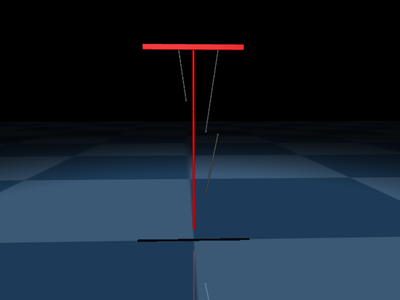

In [12]:
import random
import math
import numpy as np
from itertools import accumulate
spec = mj.MjSpec.from_string(static_model)

base_body = spec.body('Base')


# Step 1: build random bone-like rigid links (ofc, and bodies)

link_num = 3 # ignore the base
muscle_num = 3
links_list = list(range(link_num)) + [-1]    # -1 represents base
link_lengths = [0.25] * 3 + [0.4]  # assume base has -0.2->0.2
link_masses = [0.086, 0.1033, 0.1033] + [0.1]  # assume base has 0.1
cumsum = list(accumulate(link_lengths))
links_origin_vertical = [0] + list(accumulate(link_lengths))[:-2] + [0]   # using -1 to get the base pos
print(f"links_origin_vertical: {links_origin_vertical}")

link_name_from_id = {
    -1: 'Base',
    0: 'link0_body',
    1: 'link1_body',
    2: 'link2_body',
    # 3: 'link3_body', 
}

for i in range(link_num):
    link_name = 'link' + str(i) + '_body'
    geom_name = 'link' + str(i) + '_geom'
    mass = link_masses[i]
    if i == 0: 
        pos = [0, 0, 0]         # For Link0, its parents link is the base body
        _body = base_body.add_body(name=link_name, pos=pos)
    else: 
        pos = [0, 0, -link_lengths[i-1]]
        parent_link_name = 'link' + str(i-1) + '_body'
        parent_link_body = spec.body(parent_link_name)
        _body = parent_link_body.add_body(name=link_name, pos=pos)
    # add geom
    _body.add_geom(name=geom_name, size=[0.005, 0, 0], type=mj.mjtGeom.mjGEOM_CAPSULE, rgba=[0.8, 0, 0, 0.8], mass=mass, fromto = [0, 0, 0, 0, 0, -link_lengths[i]], contype=0, conaffinity=0)
    # add joint
    _body.add_joint(name='link' + str(i) + '_joint', type=mj.mjtJoint.mjJNT_HINGE, pos=[0, 0, 0], axis=[1, 0, 0], range=[-1.57, 1.57])


# Step 2: build random muscles to linked them

def add_muscle_fromto(spec, start_body_name, end_body_name, muscle_cfg):
    # TODO: Base manually here
    start_body = spec.body(start_body_name)
    add_muscle_to_spec(start_body, muscle_cfg)

    tendon_cfg = {
        'name': f"tendon_{muscle_cfg['name']}",
        'width': DEFAULT_TENDON_SIZE,
        'stiffness': DEFAULT_TENDON_STIFFNESS,
        'site1_name': f"{muscle_cfg['name']}_uSite",
        'site2_name': f"{muscle_cfg['name']}_lSite",
    }
    add_tendon_to_spec(spec, tendon_cfg)

    equality_cfg = {
        'name': f"{muscle_cfg['name']}_equality",
        'type': mj.mjtEq.mjEQ_JOINT,
        'name1': f"{muscle_cfg['name']}_mSlideJoint",
        'name2': f"{muscle_cfg['name']}_lSlideJoint",
        'solimp': [0.95, 0.99, 0.00001, 0.1, 2],
    }
    add_equality_spec(spec, equality_cfg)

    spec.add_equality(name=f"_{muscle_cfg['name']}_equality_connect", type=mj.mjtEq.mjEQ_CONNECT, name1=f"{muscle_cfg['name']}_lLink", name2=end_body_name, solimp=[0.95, 0.99, 0.00001, 0.1, 2], objtype=mj.mjtObj.mjOBJ_BODY)

    muscle_jnt_names = [f"{muscle_cfg['name']}_mSlideJoint", f"{muscle_cfg['name']}_lSlideJoint"]
    spec_new = add_motors_to_spec(spec, muscle_jnt_names, ctrlrange=(-200, 200), gear=1.0, prefix='motor_')
    return spec_new


factor_range = (0.5, 1.5)  # factor range for randomization
random.uniform(*factor_range)

posHorizonal_factor_range = (-0.2, 0.2)
posVertical_factor_range = (0.2, 0.8)

# base
base_posHorizonal_factor_range = np.array([0.2, 0.8]) - 0.5
base_posVertical_factor_range = (-0.2, 0.2)

muscle_length_factor_range = (0.8, 1.2)  # factor range for muscle length randomization
muscle_stiffness_factor_range = (0.8, 1.2)  # factor range for muscle stiffness randomization
muscle_damping_factor_range = (0.8, 1.2)  # factor range for muscle damping randomization



# set_value here
d_1 = 0.06
d_2 = 0.10
b_1 = 0.21213
b_2 = 0.1
beta_1 = 8.13 / 180 * np.pi
beta_2 = 30 / 180 * np.pi
x_3 = 0.1
y_3 = 0.1
x_4 = 0.1
y_4 = 0.05

m_3, m_4 = 0.18648, 0.27266
k_3, k_4 = 637.52/2, 631.6/2
l_10, l_20 = 0.174, 0.2562
# damping 
c_3, c_4 = 22.68/2, 21.8/2

lm_3 = 0.1033
mm_3 = 0.18
mk_3 = k_4
mc_3 = c_4
l_30 = 0.2549509756


for muscle_id in range(muscle_num):

    # assume link0 and link1, muscle3
    # selected = sorted(random.sample(links_list, 2))
    # anchor_id0 = selected[0]
    # anchor_id1 = selected[1]

    # manual set here
    if muscle_id == 0:
        anchor_id0 = -1
        anchor_id1 = 0

        pos0_x = d_1
        pos0_y = 0
        pos1_x = b_1 * math.cos(math.pi/2-beta_1)
        pos1_y = b_1 * math.sin(math.pi/2-beta_1)


    elif muscle_id == 1: 
        anchor_id0 = -1
        anchor_id1 = 1

        pos0_x = -d_2
        pos0_y = 0
        pos1_x = b_2 * math.cos(math.pi/2+beta_2)
        pos1_y = b_2 * math.sin(math.pi/2+beta_2) + links_origin_vertical[anchor_id1]

    else:
        anchor_id0 = 1
        anchor_id1 = 2

        pos0_x = -y_3
        pos0_y = x_3 + links_origin_vertical[anchor_id0]
        pos1_x = -y_4
        pos1_y = x_4 + links_origin_vertical[anchor_id1]

    # if anchor_id0 == -1:
    #     pos0_x = random.uniform(*base_posHorizonal_factor_range) * link_lengths[anchor_id0]
    #     pos0_y = random.uniform(*base_posVertical_factor_range) * link_lengths[anchor_id0] + links_origin_vertical[anchor_id0]
    #     print(pos0_x, pos0_y)
    # else:
    #     pos0_x = random.uniform(*posHorizonal_factor_range) * link_lengths[anchor_id0]
    #     pos0_y = random.uniform(*posVertical_factor_range) * link_lengths[anchor_id0] + links_origin_vertical[anchor_id0]

    # pos1_x = random.uniform(*posHorizonal_factor_range) * link_lengths[anchor_id1]
    # pos1_y = random.uniform(*posVertical_factor_range) * link_lengths[anchor_id1] + links_origin_vertical[anchor_id1]

    
    print(f"DEBUG: body0: {link_name_from_id[anchor_id0]}, pos0: ({pos0_x}, {pos0_y})")
    print(f"DEBUG: body1: {link_name_from_id[anchor_id1]}, pos1: ({pos1_x}, {pos1_y})")


    init_length = math.sqrt((pos0_x - pos1_x)**2 + (pos0_y - pos1_y)**2)
    rest_length_list = [l_10, l_20, l_30]
    stiffness_list = [k_3, k_4, mk_3]
    damping_list = [c_3, c_4, mc_3]
    # rest_length = init_length * random.uniform(*muscle_length_factor_range)
    rest_length = rest_length_list[muscle_id]
    stiffness = stiffness_list[muscle_id]
    damping = damping_list[muscle_id]
    mass_list = [m_3, m_4, mm_3]
    mass = mass_list[muscle_id]

    # muscle_cfg = {
    #     'name': f"muscle{muscle_id}",
    #     'mass': 0.18648*random.uniform(*factor_range),
    #     'stiffness': 318.76*random.uniform(*factor_range),
    #     'damping': 11.34*random.uniform(*factor_range),
    #     'init_length': init_length,
    #     'rest_length': rest_length,
    #     'base_pos': [0, -pos0_x, -pos0_y],      # pos relative to the parent link origin
    #     'base_axisangle': [1, 0, 0, math.atan2(pos1_y-pos0_y, pos1_x-pos0_x)-math.pi/2],      # axisangle relative to the parent link origin
    # }
    muscle_cfg = {
        'name': f"muscle{muscle_id}",
        'mass': mass,
        'stiffness': stiffness,
        'damping': damping,
        'init_length': init_length,
        'rest_length': rest_length,
        'base_pos': [0, -pos0_x, -pos0_y-(-links_origin_vertical[anchor_id0])],      # pos relative to the parent link origin
        'base_axisangle': [1, 0, 0, math.atan2(pos1_y-pos0_y, pos1_x-pos0_x)-math.pi/2],      # axisangle relative to the parent link origin
    }


    spec = add_muscle_fromto(spec, link_name_from_id[anchor_id0], link_name_from_id[anchor_id1], muscle_cfg)

# # add muscle
# muscle1_cfg = {
#     'name': "muscle1",
#     'mass': 0.18648*random.uniform(*factor_range),
#     'stiffness': 318.76*random.uniform(*factor_range),
#     'damping': 11.34*random.uniform(*factor_range),
#     'init_length': 0.2121301875*random.uniform(*factor_range),
#     'rest_length': 0.174*random.uniform(*factor_range),
#     'base_pos': [0, -0.06*random.uniform(*factor_range), 0],      # pos relative to the parent link origin
#     'base_axisangle': [1, 0, 0, 0.1419014548*random.uniform(*factor_range)],      # axisangle relative to the parent link origin
# }

# muscle2_cfg = {
#     'name': "muscle2",
#     'mass': 0.27266,
#     'stiffness': 315.8,
#     'damping': 10.9,
#     'init_length': 0.340296,
#     'rest_length': 0.2562,
#     'base_pos': [0, 0.1, 0],
#     'base_axisangle': [1, 0, 0, -0.147464847],
# }

# # spec = add_muscle_fromto(spec, 'Base', 'link2_body', muscle3_cfg)
# spec = add_muscle_fromto(spec, 'Base', 'link0_body', muscle1_cfg)
# spec = add_muscle_fromto(spec, 'Base', 'link1_body', muscle2_cfg)

# fix the anchor
# 强行修改anchor为000
xml_str = spec.to_xml()
import xml.etree.ElementTree as ET
# 假设 xml_str 是你的 XML 字符串
root = ET.fromstring(xml_str)
# 遍历所有 connect 标签
for conn in root.findall(".//connect"):
    conn.set("anchor", "0 0 0")
# 写回为字符串
xml_str_modified = ET.tostring(root, encoding='unicode')
spec = mj.MjSpec.from_string(xml_str_modified)


# Step 3: check the topology
model = spec.compile()
render(model)
print_xml(spec.to_xml())

# save xml
xml_script = spec.to_xml()
with open(f'test.xml', 'w') as f:
    f.write(xml_script)

In [13]:
import numpy as np

x_min = -10
x_max = 10
y_min = -10
y_max = 10
z_min = -10
z_max = 10

# 在给定范围内随机取 3D 点
min_corner = np.array([x_min, y_min, z_min])
max_corner = np.array([x_max, y_max, z_max])

point = np.random.uniform(min_corner, max_corner)
print(f"Random point in 3D space: {point}")

Random point in 3D space: [8.57580543 9.09948772 7.9935511 ]


This browser does not support the video tag.


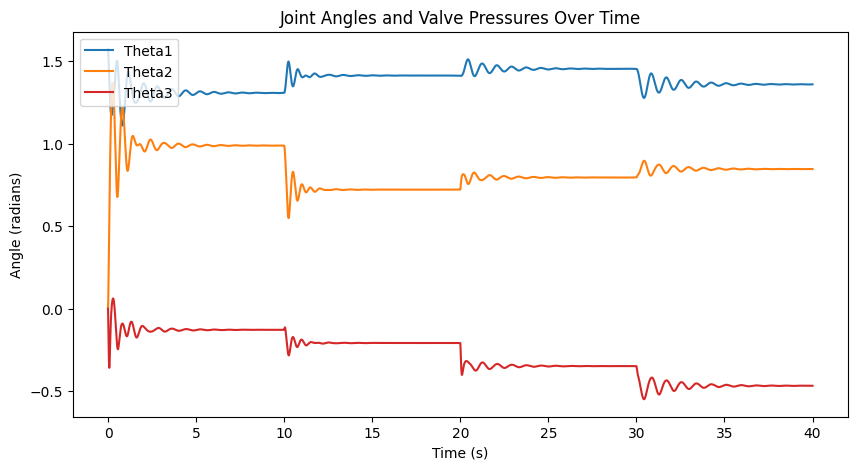

In [15]:
# load the test.xml and control
# copy from experiment_topology
# 通用实验结果，用于测试系统响应，提供视频录制结果
# 尽可能通用，为未来做强化学习做 prototype

# topology randomization

import mujoco
import numpy as np
import math
import matplotlib.pyplot as plt
import mediapy as media
from tqdm import tqdm
import time

'''
    使用相同的模型文件，参数可以修改
    input: model parameters, experiment time, step time, F1, F2, F1', F2'
    output: tracjectory of state, redering pixels array
'''

class MujocoExperiment(object):
    def __init__(self, model_path, model_type="real_geom"):
        self.model_path = model_path
        self.model = None   # wait for instantiation
        self.data = None
        # self.frames = []
        # self.tracjectory = []
        self.height = 320
        self.width = 400
        self.framerate = 60  # (Hz)
        self.model_type = model_type        # default: swing

    @staticmethod
    def calculate_length(theta1, theta2):
        a1, a2 = 0.25, 0.25
        b1, b2 = 0.21213, 0.1
        d1, d2 = 0.06, 0.10
        beta1, beta2 = np.radians(8.13), np.radians(30)

        C_x, C_y = b1 * np.cos(theta1 - beta1), b1 * np.sin(theta1 - beta1)
        D_x = a1 * np.cos(theta1) + b2 * np.cos(theta1 + theta2 + beta2)
        D_y = a1 * np.sin(theta1) + b2 * np.sin(theta1 + theta2 + beta2)

        l1 = np.hypot(d1 - C_x, 0-C_y)
        l2 = np.hypot(-d2 - D_x, 0-D_y)

        return l1, l2

    def calculate_bias(self, l10, l20):
        # if self.model_type == "real_geom":
        #     l1, l2 = MujocoExperiment.calculate_length(np.pi/2, np.pi/2) # NOTE: the init model state during loading is theta1=90, theta2=90
        # else:   # ideal_geom
        l1, l2 = MujocoExperiment.calculate_length(np.pi/2, 0)
        l1_rel = l10 - l1
        l2_rel = l20 - l2
        return l1_rel / 2, l2_rel / 2

    def apply_params(self, params):
        # update model for Experiment
        _model = mujoco.MjModel.from_xml_path(self.model_path)
        _data = mujoco.MjData(_model)
        
        # 设置关节阻尼与刚度
        # joint_ids = ["MAA", "MAA_FM", "BAA", "BAA_FM"]
        # for joint in joint_ids:
        #     idx = mujoco.mj_name2id(_model, mujoco.mjtObj.mjOBJ_JOINT, f"RB_{joint}_SlideJoint")
        #     assert idx != -1, f"Joint {joint} not found in model"
        #     # print(f"RB_{joint}_SlideJoint id: {idx}")
        #     stiffness = params['stiffness_BAA' if 'BAA' in joint else 'stiffness_MAA']
        #     damping = params['damping_BAA' if 'BAA' in joint else 'damping_MAA']
        #     _model.jnt_stiffness[idx] = stiffness * 2
        #     _model.dof_damping[idx] = damping * 2

        # 设置肩膀和肘部阻尼
        # shoulder_idx = mujoco.mj_name2id(_model, mujoco.mjtObj.mjOBJ_JOINT, "RB_Shoulder")
        # elbow_idx = mujoco.mj_name2id(_model, mujoco.mjtObj.mjOBJ_JOINT, "RB_Elbow")
        # assert shoulder_idx != -1, "Shoulder joint not found in model"
        # assert elbow_idx != -1, "Elbow joint not found in model"
        # _model.dof_damping[shoulder_idx] = params['c1_thigh']
        # _model.dof_damping[elbow_idx] = params['c2_calf']
        # print(f"RB_Shoulder id: {mujoco.mj_name2id(_model, mujoco.mjtObj.mjOBJ_JOINT, 'RB_Shoulder')}")
        # print(f"RB_Elbow id: {mujoco.mj_name2id(_model, mujoco.mjtObj.mjOBJ_JOINT, 'RB_Elbow')}")
        # print RB_Shoulder damping
        # print(f"RB_Shoulder damping: {_model.dof_damping[mujoco.mj_name2id(_model, mujoco.mjtObj.mjOBJ_JOINT, 'RB_Shoulder')]}")

        # 设置偏置
        # l1_bias, l2_bias = self.calculate_bias(params['l10'], params['l20'])
        # print(f"l1_bias: {l1_bias}, l2_bias: {l2_bias}")
        # for joint in joint_ids:
        #     idx = mujoco.mj_name2id(_model, mujoco.mjtObj.mjOBJ_JOINT, f"RB_{joint}_SlideJoint")
        #     assert idx != -1, f"Joint {joint} not found in model"
        #     # print(f"RB_{joint}_SlideJoint id: {idx}")
        #     _model.qpos_spring[idx] = l1_bias if 'MAA' in joint else l2_bias

        # old version

        # RB_BAA_SlideJoint_id = mujoco.mj_name2id(_model, mujoco.mjtObj.mjOBJ_JOINT, "RB_BAA_SlideJoint")
        # RB_BAA_FM_SlideJoint_id = mujoco.mj_name2id(_model, mujoco.mjtObj.mjOBJ_JOINT, "RB_BAA_FM_SlideJoint")
        # RB_MAA_SlideJoint_id = mujoco.mj_name2id(_model, mujoco.mjtObj.mjOBJ_JOINT, "RB_MAA_SlideJoint")
        # RB_MAA_FM_SlideJoint_id = mujoco.mj_name2id(_model, mujoco.mjtObj.mjOBJ_JOINT, "RB_MAA_FM_SlideJoint")
        # RB_Shoulder_id = mujoco.mj_name2id(_model, mujoco.mjtObj.mjOBJ_JOINT, "RB_Shoulder")
        # RB_Elbow_id = mujoco.mj_name2id(_model, mujoco.mjtObj.mjOBJ_JOINT, "RB_Elbow")

        # # read params
        # stiffness_MAA = params['stiffness_MAA']
        # stiffness_BAA = params['stiffness_BAA']
        # l10 = params['l10']
        # l20 = params['l20']
        # damping_MAA = params['damping_MAA']
        # damping_BAA = params['damping_BAA']
        # # s1 = params['s1']
        # # s2 = params['s2']
        # c1_thigh = params['c1_thigh']
        # c2_calf = params['c2_calf']

        # # 设置刚度和阻尼
        # for joint_id, stiffness, damping in zip(
        #     [RB_BAA_SlideJoint_id, RB_BAA_FM_SlideJoint_id, RB_MAA_SlideJoint_id, RB_MAA_FM_SlideJoint_id],
        #     [stiffness_BAA, stiffness_BAA, stiffness_MAA, stiffness_MAA],
        #     [damping_BAA, damping_BAA, damping_MAA, damping_MAA]
        # ):
        #     _model.jnt_stiffness[joint_id] = stiffness * 2
        #     _model.dof_damping[joint_id] = damping * 2

        # MAA_bias, BAA_bias = self.calculate_bias(l10, l20)
        # for joint_id, bias in zip(
        #     [RB_BAA_SlideJoint_id, RB_BAA_FM_SlideJoint_id, RB_MAA_SlideJoint_id, RB_MAA_FM_SlideJoint_id],
        #     [BAA_bias, BAA_bias, MAA_bias, MAA_bias]
        # ):
        #     _model.qpos_spring[joint_id] = bias

        # _model.dof_damping[RB_Shoulder_id] = c1_thigh
        # _model.dof_damping[RB_Elbow_id] = c2_calf

        self.model = _model
        self.data = _data
    
    @staticmethod
    def F1_func(t): return 0 if t < 10 else ((t//10)%3 + 1) * 2
    
    @staticmethod
    def F2_func(t): return 0 if t < 10 else (((t//10)+1)%3 + 1) * 2
    
    @staticmethod
    def F3_func(t): return 0 if t < 10 else (((t//10)+2)%3 + 1) * 2
    
    def run(self, params, time_step, duration, ifrender=True):
        self.apply_params(params)
        m, d = self.model, self.data
        # Reset state and time
        mujoco.mj_resetData(m, d)

        results = []
        frames = []
        valid = True        # check if the angle exceeds the limit
        valid_last = True

        with mujoco.Renderer(m, self.height, self.width) as renderer:
            while d.time < duration:
                d.ctrl[:2] = MujocoExperiment.F1_func(d.time)
                d.ctrl[2:4] = MujocoExperiment.F2_func(d.time)
                d.ctrl[4:] = MujocoExperiment.F3_func(d.time)
                
                theta1 = d.qpos[0] + np.pi / 2
                theta2 = d.qpos[1] + 0
                theta3 = d.qpos[2] + 0
                    
                results.append((d.time, theta1, theta2, theta3))

                # check NOTE: only consider the real geom
                # TODO: add threshold to judge the <=
                threshold = math.pi/180     # 1 deg in rad
                # NOTE: Here we wet the range of angle to be [0, pi*2/3]
                if ((np.pi/6+threshold) >= (theta1)) or ((theta1) >= (np.pi/6 + 2/3*np.pi-threshold)) or ((0+threshold) >= (theta2)) or ((theta2) >= (0+2/3*np.pi-threshold)):
                    valid = False

                mujoco.mj_step(m, d)

                if len(frames) < d.time * self.framerate:   # assume the simulation is running much faster than the rendering
                    if ifrender:
                        renderer.update_scene(d, camera="closeup")
                        frames.append(renderer.render())
            if ((np.pi/6+threshold) >= (theta1)) or ((theta1) >= (np.pi/6 + 2/3*np.pi-threshold)) or ((0+threshold) >= (theta2)) or ((theta2) >= (0+2/3*np.pi-threshold)):
                valid_last = False

        time_sim, theta1_sim, theta2_sim, theta3_sim = np.array(results).T
        return time_sim, theta1_sim, theta2_sim, theta3_sim, frames, valid, valid_last

if __name__ == "__main__":
    
    # Load the Ancestors Model
    # path = "./models/v2_4/urdf/dog2_4singleLeg_realconstrast.xml"
    # experiment_instance = MujocoExperiment(path, model_type="real_geom")

    path = "test.xml"
    experiment_instance = MujocoExperiment(path, model_type="ideal_geom_swing")

    # Model Parameter Set
    stiffness_MAA, stiffness_BAA = 318.76, 315.8
    l10, l20 = 0.174, 0.2562
    damping_MAA, damping_BAA = 11.34, 10.9
    s1, s2 = 0.000654, 0.000637
    s3 = 1
    c1_thigh, c2_calf = 0.03*0, 0.03*0
    P1 = 0/s1#50*1e3
    P2 = 0
    P3 = 0
    P1_prime = 10/s1#*1e3
    P2_prime = 5/s2#*1e3
    P3_prime = 1
    
    exp_num = 100
    np.random.seed(0)
    tic = time.time()

    params = {
        'stiffness_MAA': stiffness_MAA,
        'stiffness_BAA': stiffness_BAA,
        'l10': l10,
        'l20': l20,
        'damping_MAA': damping_MAA,
        'damping_BAA': damping_BAA,
        's1': s1,
        's2': s2,
        's3': s3,
        'c1_thigh': c1_thigh,
        'c2_calf': c2_calf,
        'P1': P1,
        'P2': P2,
        'P3': P3,
        'P1_prime': P1_prime,
        'P2_prime': P2_prime,
        'P3_prime': P3_prime
    }

    # Run the Experiments
    time_step = 10
    duration_exp = 40  # seconds
    framerate = 60
    # time_sim, theta1_sim, theta2_sim, frames, valid, valid_last, valve1, valve2 = experiment_instance.run_with_valve_dynamics(params, time_step=time_step, duration=duration_exp, ifrender=False)
    time_sim, theta1_sim, theta2_sim, theta3_sim, frames, valid, valid_last = experiment_instance.run(params, time_step=time_step, duration=duration_exp, ifrender=True)

    # show video
    media.show_video(frames, fps=framerate)
    media.write_video("./log/temp_experiment_valve_dynamics_temp0724_topology.mp4", frames, fps=framerate)

    # Plot Results with dual y-axis for pressure states
    fig, ax1 = plt.subplots(figsize=(10, 5))
    # 绘制theta1和theta2的曲线
    ax1.plot(time_sim, theta1_sim, label='Theta1', color='tab:blue')
    ax1.plot(time_sim, theta2_sim, label='Theta2', color='tab:orange')
    ax1.plot(time_sim, theta3_sim, label='Theta3', color='tab:red')
    ax1.set_xlabel('Time (s)')
    ax1.set_ylabel('Angle (radians)')
    ax1.set_title('Joint Angles and Valve Pressures Over Time')
    ax1.legend(loc='upper left')

    # 创建第二个y轴
    # ax2 = ax1.twinx()
    # ax2.plot(time_sim, valve1, label='Valve1 Pressure', color='tab:green', linestyle='--')
    # ax2.plot(time_sim, valve2, label='Valve2 Pressure', color='tab:red', linestyle='--')
    # ax2.set_ylabel('Valve Pressure')
    # ax2.legend(loc='upper right')

    plt.show()

    # save for cross-validation of the sympy implementation
    import pandas as pd
    data_traj = {
        'time': time_sim,
        'theta1': theta1_sim,
        'theta2': theta2_sim,
        'theta3': theta3_sim,
    }
    df = pd.DataFrame(data_traj)
    df.to_csv('data_mj.csv', index=False)
